In [1]:
import pandas as pd
from  VIX_trading_agent_class import Trading_Agent
from plot_vrp import plot_vrp

In [2]:
vix_options = pd.read_csv("../data/vix_options.csv",parse_dates=["as_of_date", "expiration_date"])
vix_data = pd.read_csv("../data/vix_data.csv", parse_dates=["Date"])
vvix_data = pd.read_csv("../data/vvix_data.csv", parse_dates=["Date"])
spx_data = pd.read_csv("../data/spx_data.csv", parse_dates=["Date"])

feed_start = "2024-01-01"
start_date = "2024-06-01"
end_date = "2026-05-01"

date_list = spx_data["Date"].unique()


In [22]:
agent = Trading_Agent(name="test_agent", 
    kde_rolling_window=40,
    entry_threshold=0.4,
    ewma_lambda=0.95,
    long_term_window=40,
    initial_balance=4000.0,
    k=4.0,
    Max_holding=2,
    )

for today in date_list:
    if today not in spx_data["Date"].values:
        continue

    spx = spx_data[spx_data["Date"] == today]["Close"].item()
    rv22 = spx_data[spx_data["Date"] == today]["RV22"].item() if "RV22" in spx_data.columns else 0.0
    straddle_iv = vix_data[vix_data["Date"] == today]["Close"].item() / 100.0 if today in vix_data["Date"].values else 0.2
    vrp = straddle_iv - rv22
    
    option_chain = vix_options[vix_options["as_of_date"] == today]

    agent.feed_data(stock_close=spx, rv=rv22, vrp=vrp, straddle_imp_vol=straddle_iv)
    if not option_chain.empty:
        vix_close = float(option_chain["VIX_close"].dropna().iloc[0])
        trading_signal = agent.signal()
        agent.trade(option_chain, trading_signal)
        agent.calculate_pnl(option_chain, today, vix_close)


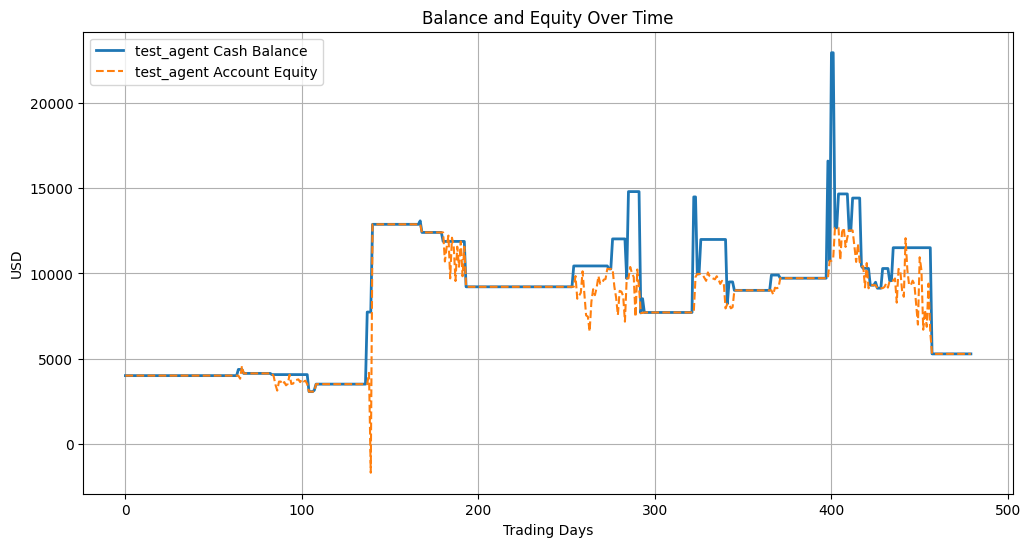

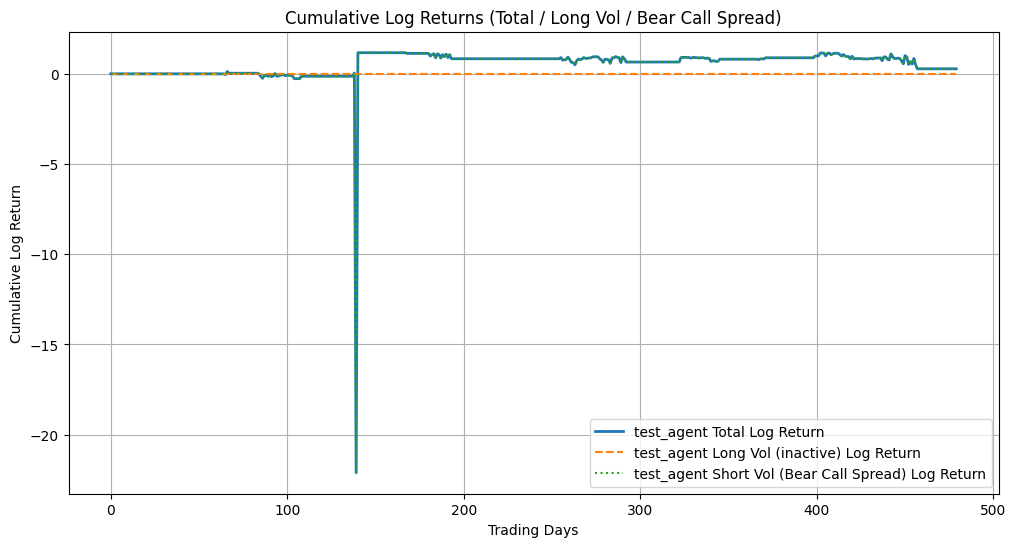


Performance Metrics for test_agent:
  Sharpe Ratio: 0.7261
  Sortino Ratio: 2944480795.1852
  Annual Return: 15.65%
  Annual Volatility: 1056853802986.41%
  Max Drawdown: -137.33%

PnL Split:
  Long Vol Realized PnL: 0.00
  Short Vol (Bear Call Spread) Realized PnL: 1276.00


In [23]:
import matplotlib.pyplot as plt

balance = agent.get_balance_history()
equity = agent.get_equity_history()
log_ret_total, log_ret_long, log_ret_short = agent.get_log_returns(initial_capital=agent.initial_balance)

plt.figure(figsize=(12, 6))
plt.plot(balance, label=f"{agent.name} Cash Balance", linewidth=2)
plt.plot(equity, label=f"{agent.name} Account Equity", linestyle="--")
plt.title("Balance and Equity Over Time")
plt.xlabel("Trading Days")
plt.ylabel("USD")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(log_ret_total, label=f"{agent.name} Total Log Return", linewidth=2)
plt.plot(log_ret_long, label=f"{agent.name} Long Vol (inactive) Log Return", linestyle="--")
plt.plot(log_ret_short, label=f"{agent.name} Short Vol (Bear Call Spread) Log Return", linestyle=":")
plt.title("Cumulative Log Returns (Total / Long Vol / Bear Call Spread)")
plt.xlabel("Trading Days")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid(True)
plt.show()

metrics = agent.get_performance_metrics(initial_capital=agent.initial_balance)
split = agent.get_long_short_pnl()
print(f"\nPerformance Metrics for {agent.name}:")
for kk, vv in metrics.items():
    if kk in ["Annual Return", "Annual Volatility", "Max Drawdown"]:
        print(f"  {kk}: {vv:.2%}")
    else:
        print(f"  {kk}: {vv:.4f}")
print("\nPnL Split:")
print(f"  Long Vol Realized PnL: {split['long_vol_pnl']:.2f}")
print(f"  Short Vol (Bear Call Spread) Realized PnL: {split['short_vol_bear_call_pnl']:.2f}")


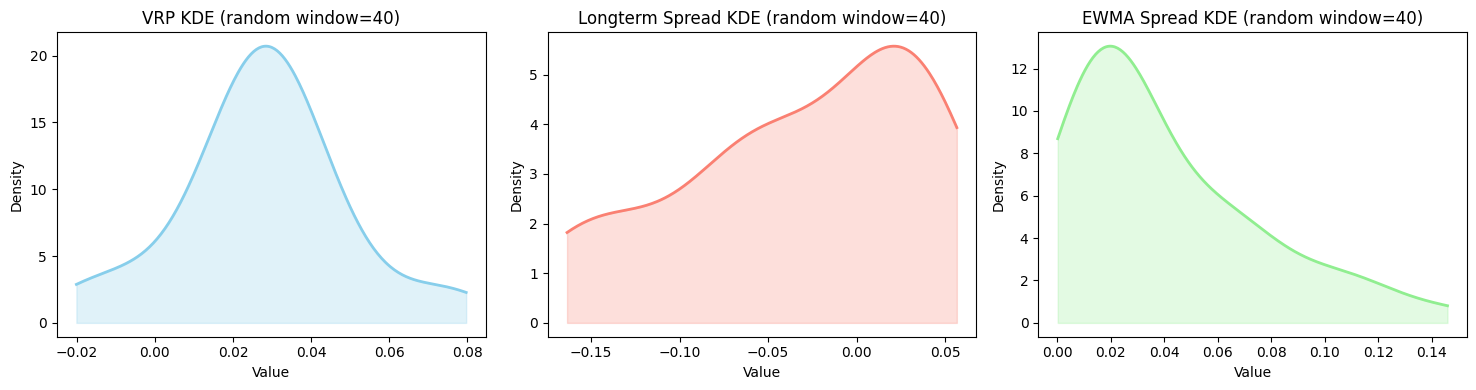

In [24]:
plot_vrp(agent)